Fault Tolerance

In [1]:
from langgraph.graph import START,END,StateGraph

In [2]:
from dotenv import load_dotenv
import os


In [3]:
from langgraph.checkpoint.memory import InMemorySaver

In [4]:
from typing import TypedDict

In [5]:
import time

In [6]:
class StateC(TypedDict):
    input:str
    step1:str
    step2:str
    done:str

In [7]:
def step1(state:StateC)->StateC:
    print("Step 1 executed")
    return {"step1":"Executed"}
def step2(state:StateC)->StateC:
    time.sleep(10)
    print("Step 2 executed")
    return {"step2":"Executed"}
def step3(state:StateC)->StateC:
    print("Step3 executed")
    return {"done":"Reached"}

In [8]:
graph=StateGraph(StateC)

In [9]:
graph.add_node(step1)

In [10]:
graph.add_node(step2)
graph.add_node(step3)

In [11]:
graph.add_edge(START,"step1")
graph.add_edge("step1","step2")
graph.add_edge("step2","step3")
graph.add_edge("step3",END)


In [12]:
checkpointer=InMemorySaver()
workflow=graph.compile(checkpointer=checkpointer)

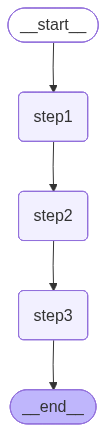

In [13]:
workflow

In [14]:
initial={'input':"start"}
workflow.invoke(initial,config={"configurable":{"thread_id":"thread-1"}})

Step 1 executed
Step 2 executed
Step3 executed


{'input': 'start', 'step1': 'Executed', 'step2': 'Executed', 'done': 'Reached'}

In [16]:
final_state = workflow.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})

In [17]:
final_state

{'input': 'start', 'step1': 'Executed', 'step2': 'Executed', 'done': 'Reached'}

In [19]:
list(workflow.get_state_history({"configurable": {"thread_id": 'thread-1'}}))

[StateSnapshot(values={'input': 'start', 'step1': 'Executed', 'step2': 'Executed', 'done': 'Reached'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f10f174-cbda-6486-8003-abaa5eba1bd5'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-02-21T11:20:17.135731+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f10f174-cbd3-6609-8002-364dc4ecf015'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step1': 'Executed', 'step2': 'Executed'}, next=('step3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f10f174-cbd3-6609-8002-364dc4ecf015'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-02-21T11:20:17.131886+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f10f174-6c6e-691f-8001-d87dbe20a96d'}}, tasks=(PregelTask(id='6

Code

In [20]:
from langchain_google_genai import ChatGoogleGenerativeAI

In [22]:
load_dotenv()
model=ChatGoogleGenerativeAI(model="gemini-flash-latest",google_api_key=os.getenv("GOOGLE_API_KEY"))

In [23]:
class JokeState(TypedDict):
    topic:str
    joke:str
    explanation:str

In [24]:
def generate_joke(state: JokeState):
    prompt = f'generate a joke on the topic {state["topic"]}'
    response = model.invoke(prompt).content
    return {'joke': response}

In [25]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = model.invoke(prompt).content

    return {'explanation': response}

In [26]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

In [27]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': [{'type': 'text',
   'text': 'A man goes into a pizza parlor and orders a whole pizza. \n\nThe cashier asks, "Should I cut it into six slices or twelve?"\n\nThe man thinks for a second and says, "Better make it six. There’s no way I could eat twelve!"',
   'extras': {'signature': 'EvoXCvcXAb4+9vsfhZH0SGXv/OdOmUqQwZiH3TdDcn3l2mC9ekoJgmmro8kcVehV9Ub294TDE2SSle+XqabEvRBAexljCW+uKW3Cl6+xHNVDLKEc7RcxzStn8EcESWM3DfexfOJttQKMNAIjOt/VDdF+3Y2WVGiaYJrh2/XlPO0W6+5sqdWFgjw6n9KKzgRotaFiYh3UKLAddiRB45TnFvVu5bfbhGG9VQphv6bAJjX6UbfGira1RA1uTC+NNYjTp2WGNutl1ZQD7nWIshrLJkM57ojpSTkdKdeZm1uCRAKlYxvbiLejPm0GyuGN11dCGBehdLhyHJ2F5/Ga4FKZMkxZrJaf/EIl03I/G7QoyIYH/hrsCSWDyMYrtljQVmQvhJsIpTYyo+5b1VNJ4dCsTBAVqc58/6nIG44/TSzwNeKFMKjdKR+i5nF386OYQQpa/h5XAyTu1IyU6ULgdqxT22kNsOHKKi4rMsOTIByToHIhyq0C3ZY/uSa2prkl8DZeBk8DYwHNZF1syAUXi0lROfy8owhkZCRHxcC9FlD6Al/CK5NmFPO5i8EBBRPh7PPjAsjB9soBBCEmRqP7W01lQyM+Zh+3ztHAjtNdH1wj5wqCeAHeVOuwGZOJPRRYoZOUUaKyUPF2Ue4WsrOPCRqUUqM/jA3lZ2A5X2T1+nO0OJa+QJ3A9J

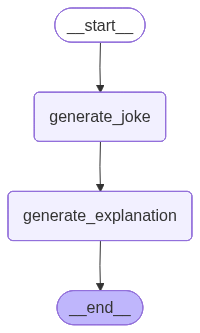

In [28]:
workflow

In [30]:
list(workflow.get_state_history({"configurable":{"thread_id":"1"}}))

[StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'A man goes into a pizza parlor and orders a whole pizza. \n\nThe cashier asks, "Should I cut it into six slices or twelve?"\n\nThe man thinks for a second and says, "Better make it six. There’s no way I could eat twelve!"', 'extras': {'signature': 'EvoXCvcXAb4+9vsfhZH0SGXv/OdOmUqQwZiH3TdDcn3l2mC9ekoJgmmro8kcVehV9Ub294TDE2SSle+XqabEvRBAexljCW+uKW3Cl6+xHNVDLKEc7RcxzStn8EcESWM3DfexfOJttQKMNAIjOt/VDdF+3Y2WVGiaYJrh2/XlPO0W6+5sqdWFgjw6n9KKzgRotaFiYh3UKLAddiRB45TnFvVu5bfbhGG9VQphv6bAJjX6UbfGira1RA1uTC+NNYjTp2WGNutl1ZQD7nWIshrLJkM57ojpSTkdKdeZm1uCRAKlYxvbiLejPm0GyuGN11dCGBehdLhyHJ2F5/Ga4FKZMkxZrJaf/EIl03I/G7QoyIYH/hrsCSWDyMYrtljQVmQvhJsIpTYyo+5b1VNJ4dCsTBAVqc58/6nIG44/TSzwNeKFMKjdKR+i5nF386OYQQpa/h5XAyTu1IyU6ULgdqxT22kNsOHKKi4rMsOTIByToHIhyq0C3ZY/uSa2prkl8DZeBk8DYwHNZF1syAUXi0lROfy8owhkZCRHxcC9FlD6Al/CK5NmFPO5i8EBBRPh7PPjAsjB9soBBCEmRqP7W01lQyM+Zh+3ztHAjtNdH1wj5wqCeAHeVOuwGZOJPRRYoZOUUaKyUPF2Ue4WsrOPCRqUUqM/jA3lZ2A5X2T

In [31]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": '1f10f185-deb4-6461-bfff-1e4cb8963621'}})

{'topic': 'pizza',
 'joke': [{'type': 'text',
   'text': 'Why did the pizza get a job?\n\nBecause it wanted to make some **dough**!',
   'extras': {'signature': 'EoISCv8RAb4+9vtIK7Zfp43AuHDn4lyAvTdOg/lB6717TC55u/M2wHfMnO2ZpFmyxlgmXAsNs7JwZaOkpQ1EQdd3hvwmLIJHPBfXMjBtcay4VF/1G4vKnMFc63wplx+RbK+BEIiuodsGEW3YT4/+4TUdhYj9TRRyuE86vXdZ78ArgCUBmOWHur8kHEaYjla8cT+jEB45Vj/3NXpkMeMtEphMJYqM9+PByh212X125Mr6r+g922nI2ezHCfVBi02pTfpE94KYpyx+KnxwCys9xPc3ZtB6IrzWG5TYYOM2L8mgRCV7LdwhtnTrgMxngpmOnm7dYKmkBImyCdMAnfXJncPSeiBRJXXbqPCxkJE0gA2sGZhx03ckQVcDoKk0PHXewuikq0nZHUENqEnIHaNHmlOs5KKCWClgFCxGXjqf/cFg21akzbGZWl2uTkifyJcn4sWf22OXAh85Kg5VOxNtHvCH4WFCco3mg9Md7JT1GMuLcEToiHeIXzP2AQBpm1xrccDsruz7EaRbDhFcC+NWU+yxdUlcDTsESIzRIDR3biwh25e+/UpYCwXwYrBLB/2ZGIdmwPQwo6LSXNASJw8MLLnhdN9M2BDtbZ+vvzozk2xtDI5TqeHPYNC5im1p1AipUDR5jJLt2AVtwZKwKxbhogJSttFk+2gU3EKFEpcbnSYfHnokp9GcrEcx317h3mnkJySVkwCs43WLboRI9UCf1Mi2B+9kRsc+HHxx21ZM9jXclYXu49EIvrp30BUCmjdRUta+/Eq6GGtM3LQhh64ES4S/JTRkqtxuQORaGjiBPymh0pUW5nuBTfDRTN2BsSeEuAFnpq

In [33]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'Why did the pizza get a job?\n\nBecause it wanted to make some **dough**!', 'extras': {'signature': 'EoISCv8RAb4+9vtIK7Zfp43AuHDn4lyAvTdOg/lB6717TC55u/M2wHfMnO2ZpFmyxlgmXAsNs7JwZaOkpQ1EQdd3hvwmLIJHPBfXMjBtcay4VF/1G4vKnMFc63wplx+RbK+BEIiuodsGEW3YT4/+4TUdhYj9TRRyuE86vXdZ78ArgCUBmOWHur8kHEaYjla8cT+jEB45Vj/3NXpkMeMtEphMJYqM9+PByh212X125Mr6r+g922nI2ezHCfVBi02pTfpE94KYpyx+KnxwCys9xPc3ZtB6IrzWG5TYYOM2L8mgRCV7LdwhtnTrgMxngpmOnm7dYKmkBImyCdMAnfXJncPSeiBRJXXbqPCxkJE0gA2sGZhx03ckQVcDoKk0PHXewuikq0nZHUENqEnIHaNHmlOs5KKCWClgFCxGXjqf/cFg21akzbGZWl2uTkifyJcn4sWf22OXAh85Kg5VOxNtHvCH4WFCco3mg9Md7JT1GMuLcEToiHeIXzP2AQBpm1xrccDsruz7EaRbDhFcC+NWU+yxdUlcDTsESIzRIDR3biwh25e+/UpYCwXwYrBLB/2ZGIdmwPQwo6LSXNASJw8MLLnhdN9M2BDtbZ+vvzozk2xtDI5TqeHPYNC5im1p1AipUDR5jJLt2AVtwZKwKxbhogJSttFk+2gU3EKFEpcbnSYfHnokp9GcrEcx317h3mnkJySVkwCs43WLboRI9UCf1Mi2B+9kRsc+HHxx21ZM9jXclYXu49EIvrp30BUCmjdRUta+/Eq6GGtM3LQhh64ES4S/JTRkqtxuQORaGjiBPymh0pUW5nuBTfD

In [34]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f06cc6e-7232-6cb1-8000-f71609e6cec5", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f10f2af-b38b-6dc7-8000-353efb7df781'}}

In [36]:
list(workflow.get_state_history({"configurable":{"thread_id":"1"}}))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f10f2af-b38b-6dc7-8000-353efb7df781'}}, metadata={'source': 'update', 'step': 0, 'parents': {}}, created_at='2026-02-21T13:41:10.303891+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f06cc6e-7232-6cb1-8000-f71609e6cec5'}}, tasks=(PregelTask(id='be280461-b7d3-aaf3-59e7-bf1635a596fe', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'Why did the pizza get a job?\n\nBecause it wanted to make some **dough**!', 'extras': {'signature': 'EoISCv8RAb4+9vtIK7Zfp43AuHDn4lyAvTdOg/lB6717TC55u/M2wHfMnO2ZpFmyxlgmXAsNs7JwZaOkpQ1EQdd3hvwmLIJHPBfXMjBtcay4VF/1G4vKnMFc63wplx+RbK+BEIiuodsGEW3YT4/+4TUdhYj9TRRyuE86vXdZ78ArgCUBmOWHur8kHEaYjla8cT+jEB45Vj/

In [38]:
workflow.invoke(None,{"configurable":{"thread_id":"1","checkpoint_id":'1f10f2af-b38b-6dc7-8000-353efb7df781'}})

{'topic': 'samosa',
 'joke': [{'type': 'text',
   'text': 'Why did the samosa go to the doctor?\n\nBecause it was feeling a bit **stuffed**, but it still had a **crusty** attitude!',
   'extras': {'signature': 'EuwQCukQAb4+9vtq/4cbtggqN/ZwG8t3RuxCUhcNlw4BAfLC1Vx959Nmd3Cz6DugyeTCcFIcuVkVdgt9LeAIWkQeQbIUbL8XfE++6f8WblY2lkC62IHwA5Fwx1PvxWgVIrf+XGwodIXShP6o1ZGaH4yk0aUEl48dpx08DIIeMWhN6kuwmyvcq/6BAbpl+w9OfN/AsH7D2CAS28AkpsG7N9DALvlssQsgMgqs/D+FgHgN8/aQKzlnLNADkG4BtFcVRxEUrbYyCm0QLsKXDGdY+IO6amZyJGZTgZBg7t5x7Ao9x1QCTk9YcZTPlccYaK5nIByBVpdI5nylRhSLGKGQAKuUBkBcys2UfFcvoAt65wesDM1EmHfS3lslsYm7NZnkWiLrCI2MffUT+cs9Jy/Z/nIax2G8fbEOgo1W/l0bwldjAteS27u7+bfejzg/t7Hi38XNrhGm1Z+hVqKLk0946ZCAIMyEdEkMX5dUCuYAwqgfKb92t48DZJQzdDwf+aQWcsqAoU7+gvtfA6Ae/EtuPubWyQ0pnU8otnunx9QJbcGa3LyGwTAgyyfUJCTugZVBqM51MWrK8rWYWrZMaZQmJsbyRf8bN10T8Z5SXfKBE3CAZFg2EAFZrgNyaRqe7UGHmIWhrgb2fqZc0aMyfIQM7X8BrKc/WtxiVsQD2OgDxBGasapah4TNYS02NtfNOzgTWkzE+4Su4LCYeJ79QLeKPhLhqqJIBYqMp8pjGlzgfGxuHNcnH1kZb2lyTjxmXMoQZNbRuKpunX28aMpTiISNN